$$\begin{aligned}
\frac{dA}{dt} &= k_r AB - k_f A*B \\[1.5ex]
\frac{dB}{dt} &= k_r AB - k_f A*B \\[1.5ex]
\frac{dAB}{dt} &= k_f A*B - k_r AB - k_m AB \\[1.5ex]
\frac{dC}{dt} &= k_m AB
\end{aligned}$$

# Import Libraries

In [55]:
import jax
import jax.numpy as jnp
import diffrax
import equinox as eqx
import lineax as lx
import optimistix as optx
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp
import random
import time

# Functions

In [ ]:
def MichMent_CPU(t, y, theta):
    A, B, AB, C = y
    kf, kr, km = theta

    dAdt = kr*AB - kf*A*B
    dBdt = kr*AB - kf*A*B
    dABdt = kf*A*B - kr*AB - km*AB
    dCdt = km*AB

    return [dAdt, dBdt, dABdt, dCdt]

def simM_CPU(ths, y0, tspan, teval):

    sims = np.zeros((np.shape(ths)[0], len(teval), 4))

    for i in range(np.shape(ths)[0]):

        params = ths[i,::]

        sol = solve_ivp(
            fun=MichMent_CPU,
            t_span=tspan,
            y0=y0,
            t_eval=teval,
            args=[params],
            method='BDF'  # Use 'Radau' or 'BDF' if the system is stiff
        )

        for j in range(4):
            sims[i,::,j] = sol.y[j]

    return sims

def plotSims1(teval, sims, N):
    plt.figure(figsize=(10, 5))

    i = 0
    for i in range(N):
        if i == 0:
            plt.plot(teval, sims[i,::,0], label='A', linewidth=0.5, c='#12988d', alpha = 0.4)
            plt.plot(teval, sims[i,::,1], label='B', linewidth=0.5, c='#439812', alpha = 0.4)
            plt.plot(teval, sims[i,::,2], label='AB', linewidth=0.5, c='#821298', alpha = 0.4)
            plt.plot(teval, sims[i,::,3], label='C', linewidth=0.5, c='#983112', alpha = 0.4)
        else:
            plt.plot(teval, sims[i,::,0], linewidth=0.5, c='#12988d', alpha = 0.4)
            plt.plot(teval, sims[i,::,1], linewidth=0.5, c='#439812', alpha = 0.4)
            plt.plot(teval, sims[i,::,2], linewidth=0.5, c='#821298', alpha = 0.4)
            plt.plot(teval, sims[i,::,3], linewidth=0.5, c='#983112', alpha = 0.4)


    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    plt.xlabel('Time')
    plt.ylabel('Population')
    plt.legend()

    plt.show()


def MichMent_GPU(t, y, args):
    A, B, AB, C = y
    kf, kr, km = args

    dAdt = kr*AB - kf*A*B
    dBdt = kr*AB - kf*A*B
    dABdt = kf*A*B - kr*AB - km*AB
    dCdt = km*AB

    return jnp.stack([dAdt, dBdt, dABdt, dCdt])

@jax.jit
def run_batch(batch_params, y0, tspan):
    def solve_single_ode(params):
        term = diffrax.ODETerm(MichMent_GPU)
        solver = diffrax.Kvaerno5()
        
        solution = diffrax.diffeqsolve(
            term,
            solver,
            t0=tspan[0], #t0,
            t1=tspan[1], #t1,
            dt0=0.01,
            y0=y0,
            args=params,
            saveat=diffrax.SaveAt(ts=jnp.linspace(tspan[0], tspan[1], 500)), #saveat,
            stepsize_controller=diffrax.PIDController(rtol=1e-3, atol=1e-6),
            # stepsize_controller=diffrax.ConstantStepSize(),
            max_steps=65536
        )
        return solution.ys
    return jax.vmap(solve_single_ode)(batch_params)

# Model Using CPU

In [118]:
np.random.seed(42)

N = 1000
ths = np.zeros((N,3))
samp1 = np.random.normal(loc=1e-2, scale=1e-3, size=N)
samp2 = np.random.normal(loc=1e-4, scale=1e-6, size=N)
samp3 = np.random.normal(loc=1e-1, scale=1e-3, size=N)

for i in range(N):
    ths[i,::] = [samp1[i], samp2[i], samp3[i]]

Execution time: 8.406835 seconds


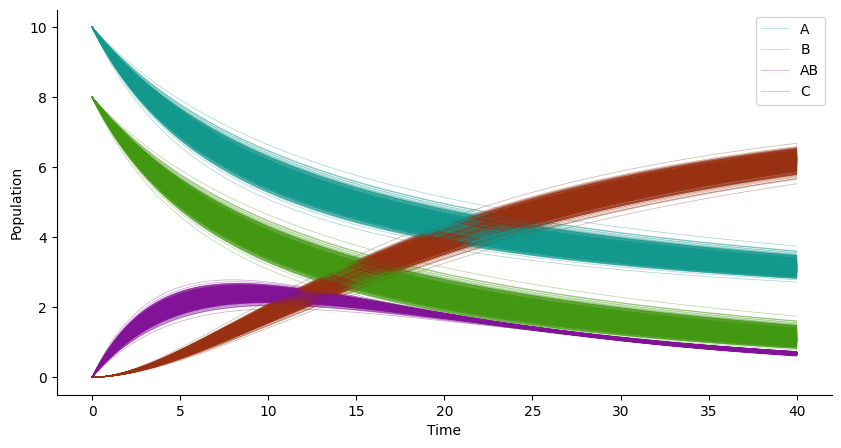

In [119]:
y0 = [10,8,0,0]
tspan = (0.0, 40.0)
teval = np.linspace(tspan[0], tspan[1], 500)

start_time = time.perf_counter()

sims = simM_CPU(ths, y0, tspan, teval)

end_time = time.perf_counter()
execution_time = end_time - start_time

print(f"Execution time: {execution_time:.6f} seconds")

plotSims1(teval, sims, N)

# Model Using GPU (JAX)

In [125]:
y0 = jnp.array([10,8,0,0])
tspan = jnp.array((0.0, 40.0))
teval = np.linspace(tspan[0], tspan[1], 500)

Execution time: 0.077210 seconds


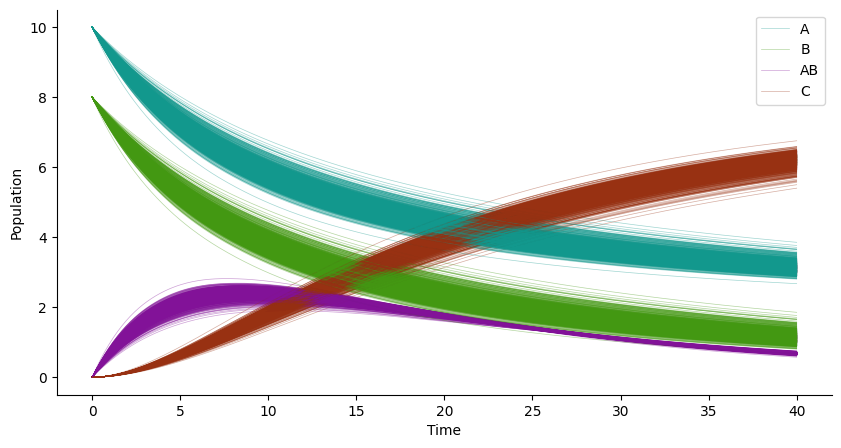

In [127]:
N = 1000
ths = np.zeros((N,3))
samp1 = np.random.normal(loc=1e-2, scale=1e-3, size=N)
samp2 = np.random.normal(loc=1e-4, scale=1e-6, size=N)
samp3 = np.random.normal(loc=1e-1, scale=1e-3, size=N)

for i in range(N):
    ths[i,::] = [samp1[i], samp2[i], samp3[i]]

batch_params = jnp.array(ths)


aa = run_batch(batch_params[0:2,::], y0, tspan)
start_time = time.perf_counter()

results = run_batch(batch_params, y0, tspan)

end_time = time.perf_counter()
execution_time = end_time - start_time

print(f"Execution time: {execution_time:.6f} seconds")

plotSims1(teval, results, N)